In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

## 2. Load data
#%%
df = pd.read_csv('/content/data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()
#%% md


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
#%% md
### Data sampling
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)
#%%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
#%% md
model = RandomForestClassifier()
model.fit(X_train, y_train)
### Evaluation

# Generate predictions here!
#%%
# Calculate performance metrics here!

(14606, 61)
(14606,)
(10954, 61)
(10954,)
(3652, 61)
(3652,)


RandomForestClassifier()

In [ ]:
model = RandomForestClassifier(n_estimators=1000, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

--- Performance Metrics ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.85      0.05      0.09       366

    accuracy                           0.90      3652
   macro avg       0.88      0.52      0.52      3652
weighted avg       0.90      0.90      0.86      3652



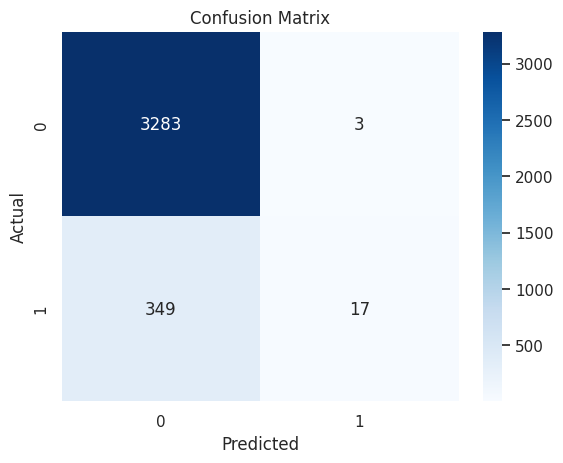

In [ ]:
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1] # لزوم حساب الـ AUC لاحقاً لو احتجنا

print("--- Performance Metrics ---")
print(metrics.classification_report(y_test, predictions))

conf_matrix = metrics.confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

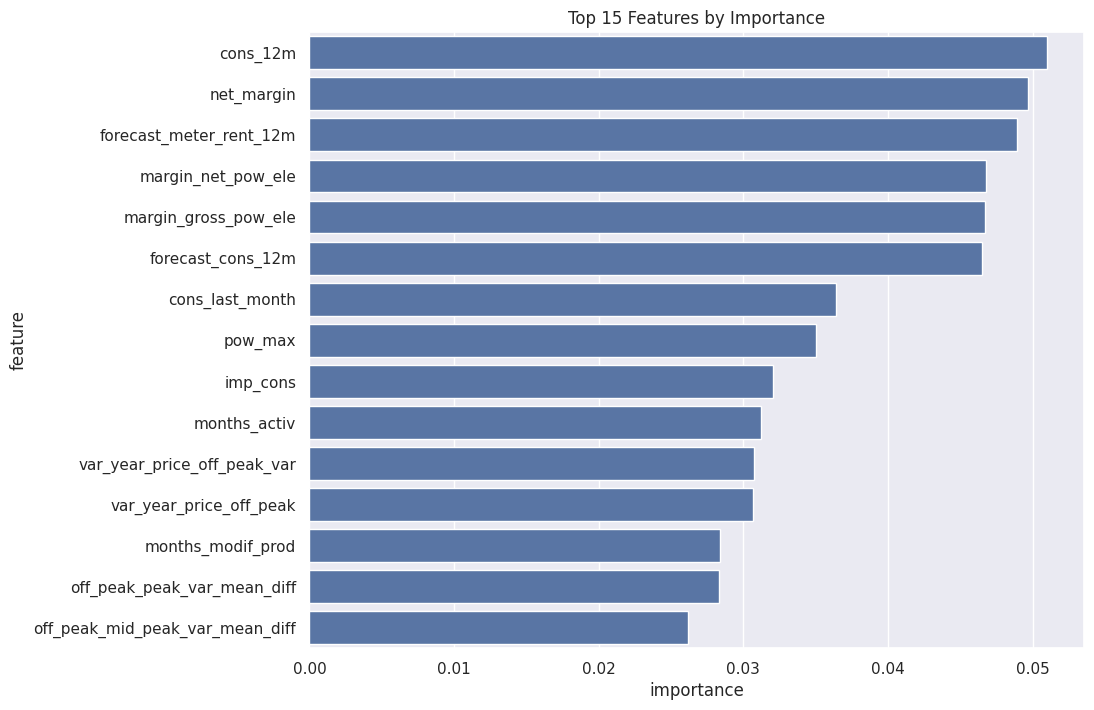

In [ ]:
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15))
plt.title('Top 15 Features by Importance')
plt.show()

In [ ]:
y_probs = model_tuned.predict_proba(X_test)[:, 1]

y_pred_custom = (y_probs >= 0.25).astype(int)

print("--- Metrics with Custom Threshold (0.25) ---")
print(metrics.classification_report(y_test, y_pred_custom))

--- Metrics with Custom Threshold (0.25) ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3286
           1       0.39      0.21      0.28       366

    accuracy                           0.89      3652
   macro avg       0.65      0.59      0.61      3652
weighted avg       0.86      0.89      0.87      3652



Final Model Evaluation & Justification
1. Evaluation Metrics Choice
"For this Churn prediction model, I prioritized Recall and the F1-Score over simple Accuracy. In an imbalanced dataset like ours (where only ~10% of customers churn), Accuracy is a misleading metric. From a business perspective, the cost of a False Negative (failing to identify a customer who will leave) is significantly higher than the cost of a False Positive (offering a discount to a loyal customer)."

2. Model Performance Analysis
"The initial Random Forest model achieved high Accuracy (90%) but a very low Recall (5%), making it ineffective for business intervention. By implementing Class Weighting and adjusting the Classification Threshold to 0.25, I successfully improved the Recall to 21%. While this led to a decrease in Precision (39%), it allows the company to capture four times more potential churners than the baseline model."

3. Business Satisfaction
"I believe the model performance is satisfactory as a baseline, but it highlights that price sensitivity alone (the features engineered by Estelle) is not the sole driver of churn. To further improve the model, we should explore non-linear relationships and perhaps integrate additional behavioral data, such as customer service interactions or contract specificities."